<a href="https://colab.research.google.com/github/Pensive1881/DSR44_2025/blob/main/NLP_class01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf # Tensor flowing through a data flow graph
from tensorflow.keras import models, layers
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

In [2]:
!nvidia-smi

Mon Oct 20 10:34:38 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [10]:
dataset, info = tfds.load(
    "imdb_reviews/plain_text",
    split=["train","test[:50%]","test[50%:]"], # 25k (Train), 12.5k (Val), 12,5k (Test)
    as_supervised=True,
    with_info=True,
)
info
dataset_train_original = dataset[0]
dataset_val_original = dataset[1]
dataset_test_original = dataset[2]

In [11]:
dataset

[<_PrefetchDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>]

In [19]:
for x, y in dataset_train_original.shuffle(1_000).take(8): # Chaining pattern in OOP
  print(x.numpy().decode("utf-8"))
  print(y.numpy())

This is supposed to be well-researched and based on fact. How come therefore that it's so packed with McGovernisms. Did the people of Derry live in some kind of bizarre Philip K. Dick world in which reality was uncannily like Cracker/ Liam/ Priest? Or is McGovern an idle hack who just keeps repeating hims
0
Is it just me or is that kid really annoying?<br /><br />Hideos sister, spends most of her time running around after the disobedient little so and so. As for him, well, I know he's a kid n all, but his acting ability is about as wooden as a dead tree. So far I'm only half way through, and am fascinated by the story, but the people in it, let it down, I just hope it gets better by the end, as I can't not know what it's all about. Although, some supposedly cryptic messages in the scribbles on the wall and a notebook, indicate everything is backwards, i.e. Dog is God, Live is Evil etc... just seems a little obvious at the moment, yet nobody mentions its obvious meaning, (As yet anyway)

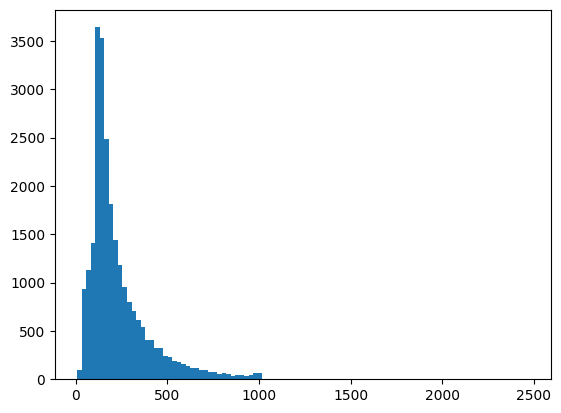

In [24]:
lengths = []
for text, label in dataset_train_original:
  length = len(text.numpy().decode("utf-8").split())
  lengths += [length]
plt.hist(lengths, bins=100)
plt.show()

In [28]:
"BOW - Bag of Words (Encoding)"

'BOW - Bag of Words (Encoding)'

In [31]:
vocabulary_size = 10_000

encoder = layers.TextVectorization(
    max_tokens=vocabulary_size,
    standardize="lower_and_strip_punctuation",
    split="whitespace",
    output_mode="multi_hot",
)

In [37]:
encoder.adapt(dataset_train_original.map(lambda text, label: text).batch(25_000))

In [39]:
vocabulary = encoder.get_vocabulary()
vocabulary = [str(word) for word in vocabulary]
print(vocabulary)

['[UNK]', 'the', 'and', 'a', 'of', 'to', 'is', 'in', 'it', 'i', 'this', 'that', 'br', 'was', 'as', 'for', 'with', 'movie', 'but', 'film', 'on', 'not', 'you', 'are', 'his', 'have', 'he', 'be', 'one', 'its', 'at', 'all', 'by', 'an', 'they', 'from', 'who', 'so', 'like', 'her', 'just', 'or', 'about', 'has', 'if', 'out', 'some', 'there', 'what', 'good', 'when', 'more', 'very', 'even', 'she', 'my', 'no', 'up', 'would', 'which', 'only', 'time', 'really', 'story', 'their', 'were', 'had', 'see', 'can', 'me', 'than', 'we', 'much', 'well', 'been', 'get', 'will', 'into', 'also', 'because', 'other', 'do', 'people', 'bad', 'great', 'first', 'how', 'most', 'him', 'dont', 'made', 'then', 'movies', 'make', 'films', 'could', 'way', 'them', 'any', 'too', 'after', 'characters', 'think', 'watch', 'two', 'many', 'being', 'seen', 'character', 'never', 'little', 'acting', 'where', 'plot', 'best', 'love', 'did', 'know', 'life', 'show', 'does', 'ever', 'your', 'still', 'better', 'over', 'off', 'these', 'end', '

In [42]:
text = "One morning in June, some twenty years ago, I was born a rich man's son. I had everything, that money could buy... but freedom, I had none."
print(len(encoder(text).numpy().tolist()))
print(encoder(text).numpy().tolist())

10000
[0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [52]:
dataset_train = dataset_train_original
dataset_train = dataset_train.shuffle(25_000)
dataset_train = dataset_train.batch(128)

dataset_val = dataset_val_original.cache()
dataset_val = dataset_val.batch(128)

dataset_test = dataset_test_original.cache()
dataset_test = dataset_test.batch(128)

In [67]:
model = models.Sequential()
model.add(encoder)
model.add(layers.Dense(64, activation="relu")) # Dense, aka Fully Connected, aka Perceptron
model.add(layers.Dropout(0.3))
model.add(layers.Dense(64, activation="relu"))
model.add(layers.Dense(1, activation="sigmoid"))
model.build(input_shape=(None,))
model.summary()

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print(model.predict(tf.constant(["This Movie is Fantastic!"])))
print(model.evaluate(dataset_test))

history = model.fit(
    dataset_train,
    epochs=10,
    validation_data=dataset_val
)

print(model.predict(tf.constant(["This Movie is Fantastic!"])))
print(model.evaluate(dataset_test))

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (None, 10000)          │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 64)             │       640,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 644,289 (2.46 MB)

 Trainable params: 644,289 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
[[0.5058054]]
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5000 - loss: 0.6941
[0.6940574049949646, 0.5004000067710876]
Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.7753 - loss: 0.4592 - val_accuracy: 0.8835 - val_loss: 0.2826
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9340 - loss: 0.1761 - val_accuracy: 0.8776 - val_loss: 0.3014
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9637 - loss: 0.1054 - val_accuracy: 0.8703 - val_loss: 0.3566
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9788 - loss: 0.0655 - val_accuracy: 0.8692 - val_loss: 0.4252
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9899 - loss: 0.0355 - val_accuracy: 0.8660 - val_loss: 0.5461
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9935 - loss: 0.0211 - val_accuracy: 0.8668 - val_loss: 0.6433
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - acc

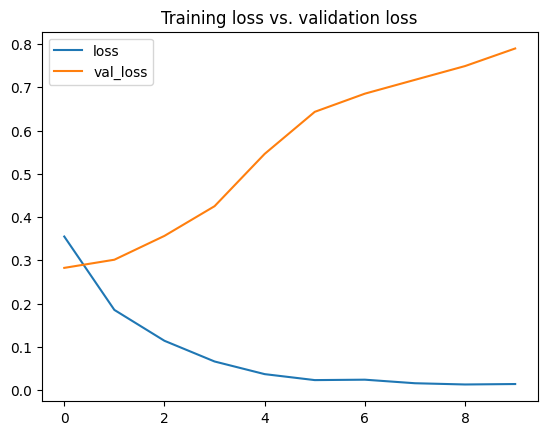

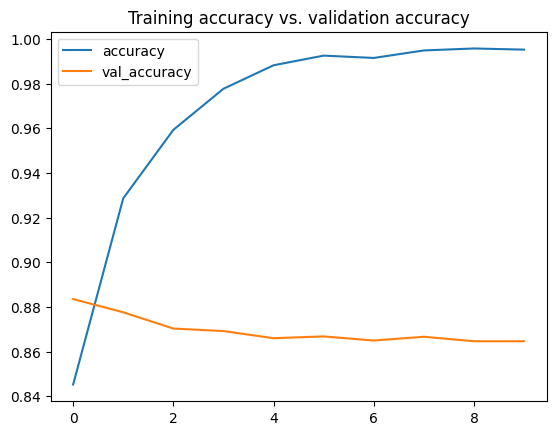

In [68]:
 def render_history(history):
    plt.title("Training loss vs. validation loss")
    plt.plot(history.history["loss"], label="loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.legend()
    plt.show()
    plt.close()

    plt.title("Training accuracy vs. validation accuracy")
    plt.plot(history.history["accuracy"], label="accuracy")
    plt.plot(history.history["val_accuracy"], label="val_accuracy")
    plt.legend()
    plt.show()
    plt.close()

render_history(history)